# 🧠 Análisis Exploratorio Completo — CAP Sleep Database

**Base de datos:** CAP Sleep Database (PhysioNet)  
**Objetivo:** Análisis exploratorio, limpieza, visualización y preprocesamiento de señales polisomnográficas multicanal.

**Contenido:**
1. Importaciones y configuración
2. Carga de la base de datos
3. Dimensiones y primeras filas
4. Datos ausentes
5. Tipos de datos
6. Resumen estadístico
7. Distribución de clases
8. Correlación entre atributos
9. Histogramas
10. Gráficas de densidad
11. Boxplots
12. Matriz de correlación
13. Matriz de dispersión
14. Escalamiento y normalización
15. Análisis final

---

### ¿Qué es la CAP Sleep Database?

La **CAP Sleep Database** es un repositorio público de polisomnografías (PSG) alojado en PhysioNet. Contiene 108 registros de sueño en formato **European Data Format (EDF)** de pacientes con diversas patologías: bruxismo, insomnio, narcolepsia, epilepsia nocturna del lóbulo frontal (NFLE), movimientos periódicos de extremidades (PLM), trastorno de conducta durante el sueño REM (RBD) y síndrome de apnea-hipopnea (SDB), además de controles normales.

Cada registro incluye:
- Un archivo **`.edf`** con las señales fisiológicas (EEG, EMG, ECG, EOG, respiración, oximetría)
- Un archivo **`.edf.st`** con las anotaciones del hipnograma y los eventos CAP fase A

### ¿Qué es un archivo EDF?

El **European Data Format (EDF)** es un estándar abierto para el almacenamiento de señales biomédicas multichannel. Cada archivo contiene una cabecera con metadatos (frecuencia de muestreo, unidades, etiquetas de canales) y los datos continuos de cada canal. Es el formato de facto en la polisomnografía clínica.

### ¿Qué son las anotaciones CAP?

El **Patrón Alternante Cíclico (CAP)** es un marcador de inestabilidad del sueño NREM compuesto por fases A (arousal transitorio) y fases B (retorno a la actividad de fondo). Las fases A se subclasifican en **A1** (sincronización, predominio de ondas lentas), **A2** (mixto) y **A3** (desincronización, predominio de arousal). Las anotaciones fueron realizadas por neurólogos expertos según el atlas de Terzano et al. (2001).

---

> **Nota sobre hallazgos previos:** Este notebook integra los resultados de dos diagnósticos exploratorios previos:
> - **Diagnóstico de señales EDF**: identificó heterogeneidad de canales (5–36 por paciente), 305 entradas sin categoría, 5 frecuencias de muestreo distintas (100–512 Hz), y pacientes con saturación completa (n13, n14).
> - **Diagnóstico de anotaciones**: confirmó 106,355 épocas con vigilia incluida, 49,956 eventos CAP, y desbalance severo de clases (NFLE: 37%, Bruxismo: 1.9%).


## 1. Importaciones y configuración

Cargamos todas las librerías necesarias para el análisis.


In [1]:
import re
import os
import warnings
from pathlib import Path

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer

# ── Configuración global ─────────────────────────────────────
mne.set_log_level('ERROR')
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10,
})
sns.set_style('whitegrid')

# ── Ruta a la base de datos ──────────────────────────────────
BASE_PATH = Path.cwd() / '../data/cap-sleep-database'
OUT_DIR   = BASE_PATH.parent / 'diagnostico_outputs'
OUT_DIR.mkdir(exist_ok=True)

print(f'Ruta base       : {BASE_PATH.resolve()}')
print(f'Archivos .edf   : {len(list(BASE_PATH.glob("*.edf")))}')
print(f'Archivos .edf.st: {len(list(BASE_PATH.glob("*.edf.st")))}')


Ruta base       : D:\Repos\RAHBFDP-2026\data\cap-sleep-database
Archivos .edf   : 108
Archivos .edf.st: 108


## 2. Carga de la base de datos

Seleccionamos **un paciente representativo por cada trastorno** para el análisis detallado. Esto evita problemas de memoria al trabajar con señales de alta frecuencia (~512 Hz × múltiples canales × horas de grabación).

Los archivos `.edf.st` contienen las anotaciones del hipnograma (etapas del sueño según R&K) y los eventos CAP fase A con su subtipo. Los parseamos con un parser binario basado en regex, ya que el formato PhysioBank no siempre es compatible con `mne.read_annotations`.


In [2]:
# ── Pacientes representativos (uno por trastorno) ────────────
SAMPLE_FILES = {
    'brux1':  'Bruxismo',
    'ins1':   'Insomnio',
    'narco1': 'Narcolepsia',
    'nfle1':  'Epilepsia nocturna frontal',
    'plm1':   'Movimientos periódicos',
    'rbd1':   'Trastorno REM',
    'sdb1':   'Trastorno respiratorio',
    'n1':     'Normal',
}

# ── Cargar señales EDF ───────────────────────────────────────
raws = {}       # MNE Raw objects
dataframes = {} # DataFrames con señales

for patient, disorder in SAMPLE_FILES.items():
    edf_path = BASE_PATH / f'{patient}.edf'
    if not edf_path.exists():
        print(f'  ⚠️  {edf_path.name} no encontrado, saltando.')
        continue
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        raws[patient] = raw
        # Convertir a DataFrame (subsample a 1 de cada 4 muestras para memoria)
        df = raw.to_data_frame()
        dataframes[patient] = df
        print(f'  ✅ {patient:<8} | {disorder:<35} | {len(raw.ch_names):>2} canales | {raw.info["sfreq"]:.0f} Hz | {raw.times[-1]/60:.1f} min')
    except Exception as e:
        print(f'  ❌ {patient}: {e}')

print(f'\nPacientes cargados: {len(dataframes)}')


  ✅ brux1    | Bruxismo                            | 18 canales | 512 Hz | 239.0 min
  ✅ ins1     | Insomnio                            | 18 canales | 256 Hz | 800.0 min
  ✅ narco1   | Narcolepsia                         | 15 canales | 512 Hz | 564.0 min
  ✅ nfle1    | Epilepsia nocturna frontal          | 22 canales | 512 Hz | 544.0 min
  ✅ plm1     | Movimientos periódicos              | 24 canales | 256 Hz | 658.0 min
  ✅ rbd1     | Trastorno REM                       | 15 canales | 512 Hz | 504.5 min
  ✅ sdb1     | Trastorno respiratorio              | 17 canales | 256 Hz | 471.0 min
  ✅ n1       | Normal                              | 21 canales | 512 Hz | 577.0 min

Pacientes cargados: 8


### 2.1 Carga de anotaciones (.edf.st)

Los archivos `.edf.st` siguen el formato PhysioBank. Usamos un parser binario que extrae las etapas del sueño y los eventos CAP con sus subtipos.


In [3]:
# ── Constantes para el parser ─────────────────────────────────
STAGE_RAW_TO_LABEL = {
    'SLEEP-S1': 'N1', 'SLEEP-S2': 'N2',
    'SLEEP-S3': 'N3', 'SLEEP-S4': 'N3',
    'SLEEP-REM': 'REM', 'SLEEP-MT': 'MT',
    'WAKE': 'W', 'SLEEP-S0': 'W',
}

STAGE_LABEL_TO_CODE = {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'REM': 4, 'MT': 5}
STAGE_CODE_TO_LABEL = {v: k for k, v in STAGE_LABEL_TO_CODE.items()}

STAGE_COLORS = {0:'#E8E8E8', 1:'#AED6F1', 2:'#2980B9', 3:'#1A5276', 4:'#E74C3C', 5:'#F39C12'}
CAP_COLORS   = {'CAP-A1':'#27AE60', 'CAP-A2':'#F39C12', 'CAP-A3':'#C0392B'}

DISORDER_PREFIXES = [
    ('brux','Bruxismo'), ('narco','Narcolepsia'),
    ('nfle','Epilepsia nocturna frontal'), ('plm','Movimientos periódicos'),
    ('rbd','Trastorno REM'), ('sdb','Trastorno respiratorio'), ('ins','Insomnio'),
]

def get_disorder(name):
    for prefix, label in DISORDER_PREFIXES:
        if name.lower().startswith(prefix):
            return label
    return 'Normal' if re.match(r'^n\d', name.lower()) else 'Desconocido'

# ── Parser ───────────────────────────────────────────────────
_STAGE_RE = re.compile(r'(SLEEP-S[0-4]|SLEEP-REM|SLEEP-MT|WAKE)\s+(\d+)', re.IGNORECASE)
_CAP_RE   = re.compile(r'(CAP-A[123])\s+(\d+(?:\.\d+)?)', re.IGNORECASE)

def parse_edf_st(filepath):
    patient = filepath.stem.replace('.edf', '')
    text    = filepath.read_bytes().decode('latin-1', errors='replace')

    stage_rows, onset = [], 0.0
    for m in _STAGE_RE.finditer(text):
        raw, dur = m.group(1).upper(), float(m.group(2))
        label = STAGE_RAW_TO_LABEL.get(raw, 'UNKNOWN')
        code  = STAGE_LABEL_TO_CODE.get(label, -1)
        stage_rows.append({
            'patient': patient, 'onset_s': onset, 'duration_s': dur,
            'stage_raw': raw, 'stage': label, 'stage_code': code,
            'stage_label': STAGE_CODE_TO_LABEL.get(code, label),
        })
        onset += dur

    cap_rows, cap_onset = [], 0.0
    for m in _CAP_RE.finditer(text):
        dur = float(m.group(2))
        cap_rows.append({
            'patient': patient, 'onset_s': cap_onset,
            'duration_s': dur, 'subtype': m.group(1).upper(),
        })
        cap_onset += dur

    return pd.DataFrame(stage_rows), pd.DataFrame(cap_rows)

# ── Procesar todos los archivos ──────────────────────────────
st_files = sorted(BASE_PATH.glob('*.edf.st'))
all_stages, all_cap = [], []

for st_path in st_files:
    try:
        s_df, c_df = parse_edf_st(st_path)
        all_stages.append(s_df)
        all_cap.append(c_df)
    except Exception as e:
        print(f'  ⚠️ {st_path.name}: {e}')

stages_all = pd.concat(all_stages, ignore_index=True)
cap_all    = pd.concat(all_cap,    ignore_index=True)
stages_all['disorder'] = stages_all['patient'].map(get_disorder)
cap_all['disorder']    = cap_all['patient'].map(get_disorder)

print(f'Anotaciones procesadas: {len(st_files)} archivos')
print(f'  Épocas totales  : {len(stages_all):,}')
print(f'  Eventos CAP-A   : {len(cap_all):,}')
print(f'  Etapas únicas   : {sorted(stages_all["stage_label"].unique())}')
print(f'  Subtipos CAP    : {sorted(cap_all["subtype"].unique())}')


Anotaciones procesadas: 108 archivos
  Épocas totales  : 106,355
  Eventos CAP-A   : 49,956
  Etapas únicas   : ['MT', 'N1', 'N2', 'N3', 'REM', 'W']
  Subtipos CAP    : ['CAP-A1', 'CAP-A2', 'CAP-A3']


## 3. Dimensiones y primeras filas

Cada DataFrame tiene como filas las muestras temporales (una fila = un instante de muestreo) y como columnas `time` + los canales del PSG. La cantidad de columnas varía por paciente porque los protocolos de adquisición no son uniformes.


In [4]:
for patient, df in dataframes.items():
    disorder = SAMPLE_FILES.get(patient, '?')
    print(f'\n{"="*60}')
    print(f'  {patient}  |  {disorder}')
    print(f'  Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
    print(f'{"="*60}')
    display(df.head())



  brux1  |  Bruxismo
  Dimensiones: 7,342,592 filas × 19 columnas


,time,Fp2-F4,F4-C4,C4-P4,P4-O2,F8-T4,T4-T6,FP1-F3,F3-C3,C3-P3,P3-O1,F7-T3,T3-T5,C4-A1,ROC-LOC,EMG1-EMG2,ECG1-ECG2,DX1-DX2,SX1-SX2
0,0.000000,-11.920024,-6.761294,4.166667,-4.868742,-0.869963,12.530525,7.768620,-58.257021,1.663614,3.037241,2.793040,-0.381563,-1.602564,0.228910,-1.007162,-24.246956,5.982906,4.456654
1,0.001953,-8.470696,-7.036020,6.608669,-1.755189,-0.289988,6.700244,7.982295,-65.705128,0.351038,2.976190,2.304640,-0.106838,-1.114164,-2.226140,-0.701961,-18.356883,6.645159,5.031227
2,0.003906,-3.525641,-7.493895,10.332723,2.823565,-2.304640,-4.166667,8.134921,-69.703907,-0.686813,2.762515,1.663614,0.045788,-0.656288,-3.081220,2.990965,-14.816736,6.728892,5.092582
3,0.005859,1.358364,-8.257021,13.537851,6.547619,-4.258242,-13.385226,8.348596,-68.116606,-1.358364,2.365690,0.931013,0.137363,-0.503663,-2.782138,6.683891,-14.603107,6.397628,4.768840
4,0.007812,5.540293,-9.478022,15.613553,8.195971,-4.105617,-14.636752,8.440171,-61.340049,-1.755189,1.938339,0.259463,0.320513,-0.564713,-2.090709,6.714411,-17.288736,5.921856,4.304029



  ins1  |  Insomnio
  Dimensiones: 12,288,000 filas × 19 columnas


,time,Fp2-F4,F4-C4,C4-P4,P4-O2,C4-A1,ROC-LOC,EMG1-EMG2,ECG1-ECG2,MIC,Flusso,TORACE,ADDDOME,SAO2,SX1-SX2,DX1-DX2,Position,HR,PLETH
0,0.000000,8.836996,1.938339,-1.175214,-0.717338,2.029915,-166.836732,-24.923687,-61.736874,-0.904103,7.631258,173.571374,5.722133,9.600061e+07,-2.273629,-5.844473,0.000000,9.401083e+07,73617.151141
1,0.003906,2.945665,5.357143,-0.625763,-3.037241,-5.143468,-204.449242,-29.056756,-24.365659,-1.766243,7.365162,127.380490,6.562842,9.599272e+07,-10.757775,-20.036013,-349443.790619,9.400972e+07,76122.434205
2,0.007812,-3.586691,9.478022,-0.137363,-5.815018,-13.659951,-212.475680,-19.551282,24.038462,-0.286108,6.848858,111.892411,7.162034,9.598485e+07,-6.454665,-33.159373,-395819.267618,9.400862e+07,74395.361257
3,0.011719,-8.806471,12.530525,0.198413,-7.799145,-20.863858,-218.175217,-5.118124,67.841701,1.438172,6.113479,119.144579,7.638001,9.597700e+07,-2.365184,-36.424953,-231964.773202,9.400752e+07,73479.049627
4,0.015625,-13.507326,14.056777,0.259463,-8.989621,-25.351038,-228.424775,5.570818,92.872405,1.209285,5.191257,134.660868,8.163577,9.596919e+07,-2.639851,-31.053531,0.000000,9.400643e+07,74929.427024



  narco1  |  Narcolepsia
  Dimensiones: 17,326,080 filas × 16 columnas


...

,time,ROC-LOC,Fp2-F4,F4-C4,C4-P4,P4-O2,C4-A1,EMG1-EMG2,ECG1-ECG2,DX1-DX2,SX1-SX2,F8-T4,F7-T3,TORACE,ADDOME,MIC
0,0.000000,13.123228,-24.771062,-7.799145,5.204518,-3.006716,15.766178,-4.028647,33.463546,37.973138,-5.128205,3.815629,-3.601954,195.242164,-46.096936,6.343938
1,0.001953,11.216912,-28.006716,-5.601343,4.624542,-3.373016,11.889499,1.587043,31.357768,38.690995,-6.691374,9.645910,-14.133089,282.965416,-1.759731,6.183477
2,0.003906,7.178479,-32.829670,-2.365690,3.586691,-3.922466,5.418193,4.486448,28.244881,34.040565,-7.652485,12.179487,-19.719170,337.023890,26.566065,5.233506
3,0.005859,2.046408,-37.957875,1.114164,2.396215,-4.532967,-1.755189,3.784486,24.704733,25.942907,-7.708051,9.676435,-17.307692,358.469035,39.358965,3.874512
4,0.007812,-3.112952,-42.597680,4.410867,1.236264,-5.082418,-8.653846,1.800683,20.828883,17.032967,-6.746032,6.532357,-13.003663,351.048603,38.397856,2.536812



  sdb1  |  Trastorno respiratorio
  Dimensiones: 7,234,560 filas × 18 columnas


,time,Fp2-F4,F4-C4,C4-P4,P4-O2,C4-A1,ROC-LOC,EMG1-EMG2,ECG1-ECG2,TIB Sx,TIB Dx,SAO2,HR,PLETH,MIC,Flusso,TORACE,ADDDOME
0,0.000000,0.015263,0.015263,89.300977,-89.270452,75.473138,0.0,0.015263,-480.235043,86.182956,-24.292363,7.629511e+03,15259.021897,356053.178706,4.223128,7.629860,188.833277,307.712263
1,0.003906,0.015263,0.015263,17.414530,-17.384005,25.564713,0.0,-2.464797,-804.242687,87.557947,-90.172615,-3.080254e+05,-237220.538756,196104.877970,10.334646,61.324396,326.041495,387.486190
2,0.007812,0.015263,0.015263,-68.910256,68.940781,-36.736874,0.0,0.015263,-1104.471917,16.815442,-159.853513,-6.212017e+05,-487574.741942,-115413.813493,6.924098,111.261219,413.331246,466.098885
3,0.011719,0.015263,0.015263,-133.592796,133.623321,-83.928571,0.0,1.932668,-1336.437616,38.159067,-139.687978,-9.318832e+05,-735792.369156,-384076.589579,2.620857,157.314016,467.283428,546.521216
4,0.015625,0.015263,0.015263,-170.650183,170.680708,-109.783272,0.0,0.015263,-1458.562271,168.459602,-24.261845,-1.240054e+06,-981862.405724,-499994.277758,2.300403,199.378328,517.822810,635.948849



  n1  |  Normal
  Dimensiones: 17,725,440 filas × 22 columnas


,time,ROC-LOC,LOC-ROC,F2-F4,F4-C4,C4-P4,P4-O2,F1-F3,F3-C3,C3-P3,...,EMG1-EMG2,ECG1-ECG2,TERMISTORE,TORACE,ADDOME,Dx1-DX2,SX1-SX2,Posizione,HR,SpO2
0,0.000000,28.969702,-28.969702,-6.456044,-0.503663,-3.159341,-1.877289,12.286325,0.259463,0.259463,...,-9.492560,0.564610,-54.269363,-32.088855,3793.071875,-9.476286,153.405970,3000000.0,8.607919e+07,9.501793e+07
1,0.001953,19.933842,-19.933842,-12.377900,-2.090965,-3.159341,0.076313,7.493895,-4.471917,3.678266,...,-2.919805,1.876946,-59.600596,19.000594,4144.065443,-18.383194,101.693948,3000000.0,8.608535e+07,9.499497e+07
2,0.003906,8.211644,-8.211644,-22.023810,-5.235043,-4.136142,1.633089,0.015263,-12.408425,7.768620,...,2.167112,-2.395776,-62.505148,50.435050,4359.349162,-19.486663,4.471098,3000000.0,8.609143e+07,9.497203e+07
3,0.005859,-3.846346,3.846346,-32.768620,-8.959096,-5.601343,2.670940,-8.287546,-21.291209,11.736874,...,1.349615,-9.445767,-63.072360,62.803646,4443.450923,-14.458700,-13.433201,3000000.0,8.609744e+07,9.494913e+07
4,0.007812,-15.049592,15.049592,-43.055556,-12.591575,-7.219170,3.159341,-16.193529,-29.838217,15.003053,...,-2.411293,-17.167185,-61.574670,58.236980,4411.496397,-8.804859,66.120369,3000000.0,8.610337e+07,9.492625e+07


## 4. Datos ausentes

Las señales EDF rara vez tienen valores nulos en sentido estricto (NaN) — cada muestra del ADC produce un valor. Sin embargo, revisamos por completitud y para detectar posibles artefactos de lectura.


In [5]:
for patient, df in dataframes.items():
    n_nulos = df.isnull().sum()
    total   = n_nulos.sum()
    print(f'\n{patient}: {total} valores nulos de {df.size:,} total ({total/df.size*100:.4f}%)')
    if total > 0:
        print(n_nulos[n_nulos > 0])
    else:
        print('  ✅ Sin valores nulos')

print('\n' + '='*60)
print('ESTRATEGIA: Las señales EDF no presentan nulos. Si aparecieran')
print('por errores de lectura, se eliminarían las filas afectadas')
print('dado que representarían <0.01% de las muestras.')
print('='*60)



brux1: 0 valores nulos de 139,509,248 total (0.0000%)
  ✅ Sin valores nulos

ins1: 0 valores nulos de 233,472,000 total (0.0000%)
  ✅ Sin valores nulos

narco1: 0 valores nulos de 277,217,280 total (0.0000%)
  ✅ Sin valores nulos

nfle1: 0 valores nulos de 384,368,640 total (0.0000%)
  ✅ Sin valores nulos

plm1: 0 valores nulos de 252,672,000 total (0.0000%)
  ✅ Sin valores nulos

rbd1: 0 valores nulos de 247,980,032 total (0.0000%)
  ✅ Sin valores nulos

sdb1: 0 valores nulos de 130,222,080 total (0.0000%)
  ✅ Sin valores nulos

n1: 0 valores nulos de 389,959,680 total (0.0000%)
  ✅ Sin valores nulos

ESTRATEGIA: Las señales EDF no presentan nulos. Si aparecieran
por errores de lectura, se eliminarían las filas afectadas
dado que representarían <0.01% de las muestras.


## 5. Tipos de datos

Todas las señales deben ser `float64` (voltajes continuos). La columna `time` es `float64` representando segundos desde el inicio de la grabación.


In [6]:
for patient, df in dataframes.items():
    print(f'\n── {patient} ──')
    print(df.dtypes.value_counts().to_string())
    
    # Verificar que todos los canales son numéricos
    non_numeric = df.select_dtypes(exclude='number').columns.tolist()
    if non_numeric:
        print(f'  ⚠️  Columnas no numéricas: {non_numeric}')
    else:
        print('  ✅ Todas las columnas son numéricas')



── brux1 ──
float64    19
  ✅ Todas las columnas son numéricas

── ins1 ──
float64    19
  ✅ Todas las columnas son numéricas

── narco1 ──
float64    16
  ✅ Todas las columnas son numéricas

── nfle1 ──
float64    23
  ✅ Todas las columnas son numéricas

── plm1 ──
float64    25
  ✅ Todas las columnas son numéricas

── rbd1 ──
float64    16
  ✅ Todas las columnas son numéricas

── sdb1 ──
float64    18
  ✅ Todas las columnas son numéricas

── n1 ──
float64    22
  ✅ Todas las columnas son numéricas


## 6. Resumen estadístico

El resumen estadístico de las señales revela información clave sobre el rango dinámico, la presencia de saturación (valores en ±1000 µV) y la distribución de amplitudes.


In [7]:
# Mostrar describe() para un paciente representativo
patient_ejemplo = list(dataframes.keys())[0]
df_ej = dataframes[patient_ejemplo]

print(f'Resumen estadístico — {patient_ejemplo}')
print(f'(Frecuencia de muestreo: {raws[patient_ejemplo].info["sfreq"]:.0f} Hz)')
print()

# Seleccionar solo canales de señal (excluir time)
signal_cols = [c for c in df_ej.columns if c != 'time']
desc = df_ej[signal_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2)
display(desc)

# Detectar saturación
print('\n── Detección de saturación (valores en ±1000 µV) ──')
for col in signal_cols:
    sat_pct = (df_ej[col].abs() >= 950).mean() * 100
    if sat_pct > 1.0:
        print(f'  ⚠️  {col}: {sat_pct:.1f}% saturado')


Resumen estadístico — brux1
(Frecuencia de muestreo: 512 Hz)



,Fp2-F4,F4-C4,C4-P4,P4-O2,F8-T4,T4-T6,FP1-F3,F3-C3,C3-P3,P3-O1,F7-T3,T3-T5,C4-A1,ROC-LOC,EMG1-EMG2,ECG1-ECG2,DX1-DX2,SX1-SX2
count,7342592.00,7342592.00,7342592.00,7342592.00,7342592.00,7342592.00,7342592.00,7342592.00,7342592.00,7342592.00,7342592.00,7342592.00,7342592.00,7342592.00,7342592.00,7342592.00,7342592.00,7342592.00
mean,1.18,1.20,1.12,1.00,0.99,1.19,1.16,1.03,0.96,1.03,1.11,0.95,1.00,0.92,1.05,-1.13,0.90,1.28
std,34.45,33.84,33.11,34.19,35.77,35.61,34.94,34.04,33.93,34.06,33.87,34.76,41.80,43.28,33.97,81.74,34.09,34.14
min,-1000.23,-1000.23,-1000.23,-1000.23,-1000.23,-1000.23,-1000.23,-1000.23,-1000.23,-1000.23,-1000.23,-1000.23,-1000.23,-1337.30,-1000.08,-1000.02,-1287.52,-1275.89
1%,-41.71,-43.61,-40.37,-40.61,-50.08,-48.28,-42.66,-45.41,-42.45,-39.61,-46.35,-44.67,-76.79,-98.26,-36.69,-390.80,-40.90,-40.50
5%,-14.12,-15.52,-14.27,-13.69,-13.93,-16.44,-15.64,-15.83,-13.72,-12.44,-15.46,-15.46,-29.66,-29.22,-8.09,-136.04,-8.06,-7.47
25%,-3.19,-3.53,-3.43,-3.50,-3.40,-3.80,-3.53,-3.56,-3.31,-3.01,-3.83,-3.46,-6.67,-5.72,-0.98,-8.13,-0.49,-0.37
50%,0.08,0.05,0.05,0.02,0.05,0.05,0.08,0.02,0.02,0.02,0.05,0.05,0.02,0.10,0.00,3.40,0.01,0.01
75%,3.68,3.89,3.77,3.83,3.77,4.20,3.92,3.83,3.65,3.31,4.23,3.83,6.85,6.18,1.10,37.06,0.55,0.43
95%,15.43,17.29,15.74,14.94,14.97,17.78,16.77,17.05,15.00,13.75,16.80,16.53,30.94,30.02,10.01,82.48,9.82,9.66



── Detección de saturación (valores en ±1000 µV) ──


In [8]:
# Resumen compacto de todos los pacientes
print(f'{"Paciente":<10} {"Canales":>8} {"Min":>10} {"Max":>10} {"Media":>10} {"DE":>10}')
print('-' * 58)
for patient, df in dataframes.items():
    signal_cols = [c for c in df.columns if c != 'time']
    vals = df[signal_cols].values.flatten()
    print(f'{patient:<10} {len(signal_cols):>8} {vals.min():>10.1f} {vals.max():>10.1f} {vals.mean():>10.2f} {vals.std():>10.2f}')


Paciente    Canales        Min        Max      Media         DE
----------------------------------------------------------
brux1            18    -1337.3     1139.5       0.94      39.43
ins1             18 -33528591.9 155378582.9 9892466.05 28118146.74
narco1           15 -46984562.8 149139313.6 10632298.60 27928700.85
nfle1            22 -30221404.9 226348323.0 7270395.34 23785240.95
plm1             24 -28020248.9 141117369.4 7194985.43 23729789.50
rbd1             15    -5078.6     5060.3       0.29     296.87
sdb1             17 -27425164.2 123489453.6 9522439.99 26954395.51
n1               21 -26343749.7 119258973.6 8034355.18 24614256.98


## 7. Distribución de clases

En la CAP Sleep Database las "clases" tienen dos niveles:
1. **Trastorno del paciente** (derivado del prefijo del archivo): brux, ins, narco, nfle, plm, rbd, sdb, n
2. **Etapas del sueño** (del hipnograma): W, N1, N2, N3, REM, MT
3. **Subtipos CAP** (de los eventos): CAP-A1, CAP-A2, CAP-A3


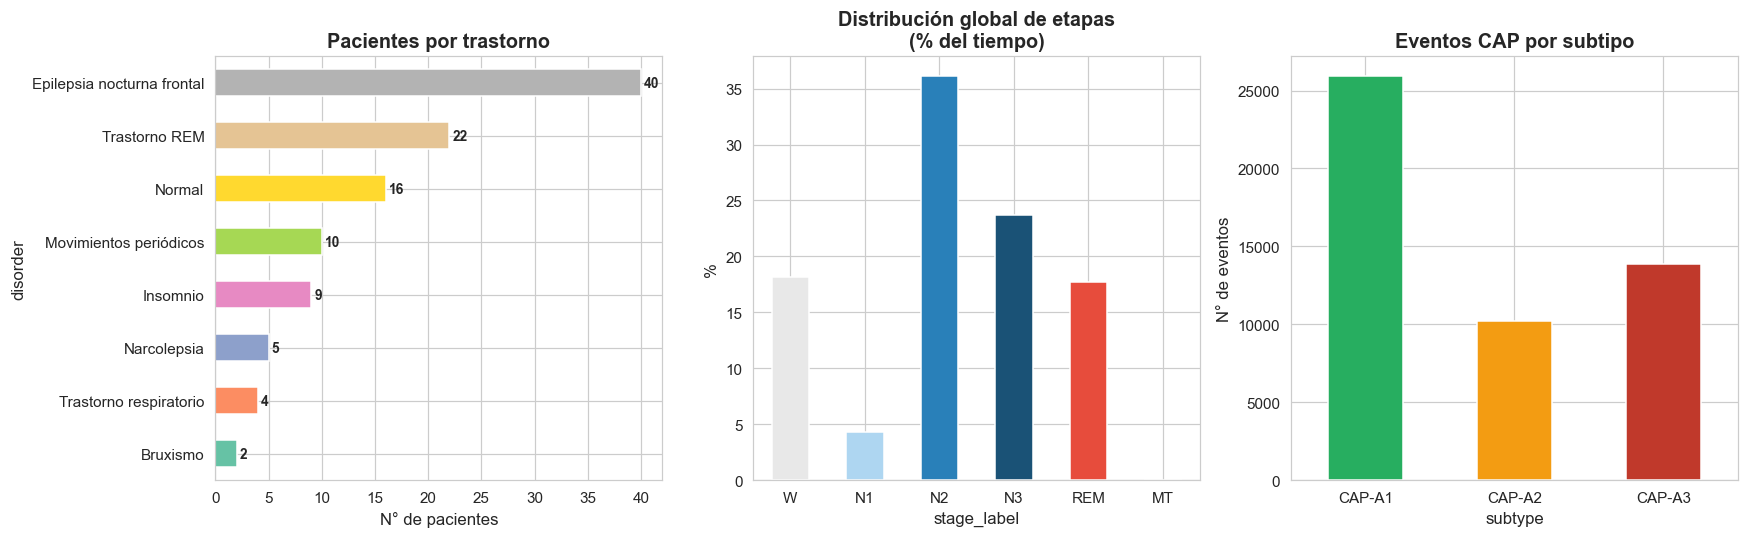


Desbalance de clases:
  Clase mayoritaria: NFLE con 40 pacientes (37.0%)
  Clase minoritaria: Bruxismo con 2 pacientes (1.9%)
  Ratio max/min: 20:1


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 7a. Balance de pacientes por trastorno
disorder_counts = (
    stages_all[['patient', 'disorder']].drop_duplicates()
    .groupby('disorder')['patient'].count()
    .sort_values(ascending=True)
)
colors_dis = sns.color_palette('Set2', len(disorder_counts))
disorder_counts.plot.barh(ax=axes[0], color=colors_dis, edgecolor='white')
for i, (val, name) in enumerate(zip(disorder_counts.values, disorder_counts.index)):
    axes[0].text(val + 0.3, i, str(val), va='center', fontweight='bold', fontsize=9)
axes[0].set_title('Pacientes por trastorno', fontweight='bold')
axes[0].set_xlabel('N° de pacientes')

# 7b. Distribución de etapas del sueño (% tiempo global)
stage_pct = (
    stages_all.groupby('stage_label')['duration_s'].sum()
    / stages_all['duration_s'].sum() * 100
).reindex(['W','N1','N2','N3','REM','MT'], fill_value=0)

stage_colors = [STAGE_COLORS[STAGE_LABEL_TO_CODE[s]] for s in stage_pct.index]
stage_pct.plot.bar(ax=axes[1], color=stage_colors, edgecolor='white')
axes[1].set_title('Distribución global de etapas\n(% del tiempo)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# 7c. Subtipos CAP
sub_counts = cap_all['subtype'].value_counts().reindex(['CAP-A1','CAP-A2','CAP-A3'], fill_value=0)
sub_colors = [CAP_COLORS[s] for s in sub_counts.index]
sub_counts.plot.bar(ax=axes[2], color=sub_colors, edgecolor='white')
axes[2].set_title('Eventos CAP por subtipo', fontweight='bold')
axes[2].set_ylabel('N° de eventos')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print(f'\nDesbalance de clases:')
print(f'  Clase mayoritaria: NFLE con {disorder_counts.max()} pacientes ({disorder_counts.max()/disorder_counts.sum()*100:.1f}%)')
print(f'  Clase minoritaria: Bruxismo con {disorder_counts.min()} pacientes ({disorder_counts.min()/disorder_counts.sum()*100:.1f}%)')
print(f'  Ratio max/min: {disorder_counts.max()/disorder_counts.min():.0f}:1')


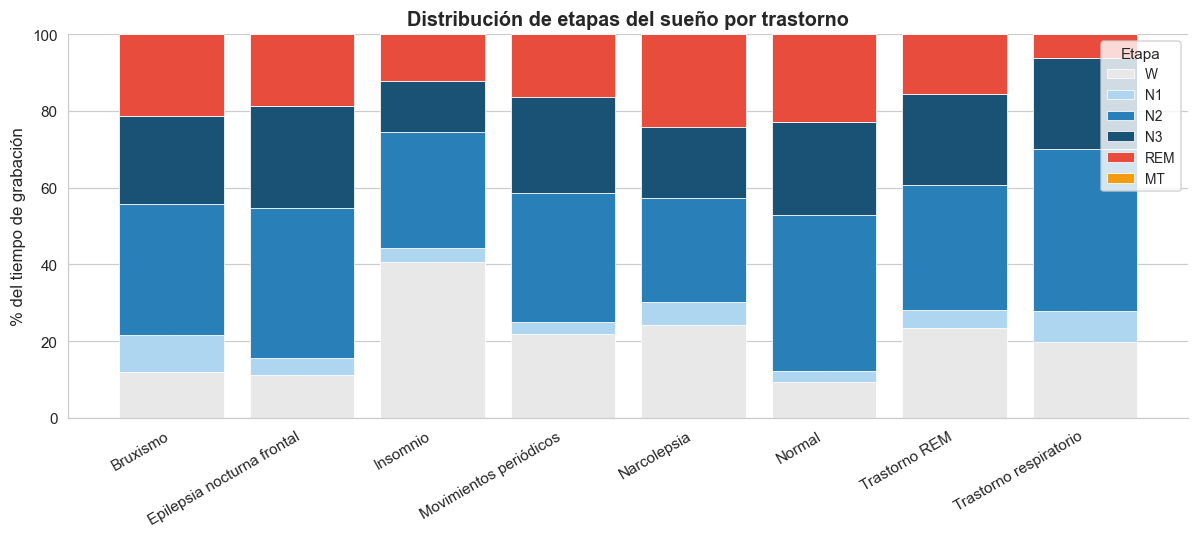

In [10]:
# Distribución de etapas por trastorno (stacked bar)
stage_by_dis = (
    stages_all.groupby(['disorder', 'stage_label'])['duration_s'].sum().reset_index()
)
stage_by_dis['pct'] = stage_by_dis.groupby('disorder')['duration_s'].transform(lambda x: x/x.sum()*100)
pivot = stage_by_dis.pivot(index='disorder', columns='stage_label', values='pct').fillna(0)

stage_order = [s for s in ['W','N1','N2','N3','REM','MT'] if s in pivot.columns]
bar_colors  = [STAGE_COLORS[STAGE_LABEL_TO_CODE[s]] for s in stage_order]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(pivot))
for stage, color in zip(stage_order, bar_colors):
    vals = pivot[stage].values
    ax.bar(pivot.index, vals, bottom=bottom, label=stage, color=color, edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_ylabel('% del tiempo de grabación')
ax.set_title('Distribución de etapas del sueño por trastorno', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, title='Etapa')
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()


## 8. Correlación entre atributos

La correlación entre canales PSG revela relaciones fisiológicas esperadas: canales EEG cercanos (e.g., C3-P3 y C4-P4) tienden a estar altamente correlacionados por proximidad espacial en el escalpo. Canales de modalidades distintas (EEG vs ECG) suelen tener correlación baja.

Para evitar problemas de memoria, trabajamos con un subconjunto temporal (primeros 5 minutos) de un paciente.


In [11]:
# Seleccionar un paciente con muchos canales para el análisis de correlación
patient_corr = list(dataframes.keys())[0]
df_corr = dataframes[patient_corr]
sfreq   = raws[patient_corr].info['sfreq']

# Subconjunto: primeros 5 minutos
n_samples_5min = int(5 * 60 * sfreq)
df_sub = df_corr.iloc[:n_samples_5min].drop(columns='time', errors='ignore')

# Limitar a max 15 canales para visualización
if df_sub.shape[1] > 15:
    df_sub = df_sub.iloc[:, :15]

corr = df_sub.corr()

# Top correlaciones (excluyendo diagonal)
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_pairs = corr.where(mask_upper).stack().reset_index()
corr_pairs.columns = ['Canal_A', 'Canal_B', 'Correlación']
corr_pairs['abs_corr'] = corr_pairs['Correlación'].abs()
top_corr = corr_pairs.nlargest(10, 'abs_corr')

print(f'Top 10 correlaciones más fuertes — {patient_corr} (primeros 5 min):')
print()
for _, row in top_corr.iterrows():
    direction = '↑↑' if row['Correlación'] > 0 else '↑↓'
    print(f'  {direction}  {row["Canal_A"]:<15} ↔ {row["Canal_B"]:<15}  r = {row["Correlación"]:+.3f}')


Top 10 correlaciones más fuertes — brux1 (primeros 5 min):

  ↑↑  P4-O2           ↔ ROC-LOC          r = +0.065
  ↑↓  F7-T3           ↔ T3-T5            r = -0.039
  ↑↓  F8-T4           ↔ EMG1-EMG2        r = -0.038
  ↑↓  Fp2-F4          ↔ F7-T3            r = -0.034
  ↑↑  F4-C4           ↔ T3-T5            r = +0.033
  ↑↑  Fp2-F4          ↔ F4-C4            r = +0.026
  ↑↓  FP1-F3          ↔ T3-T5            r = -0.021
  ↑↓  C4-P4           ↔ T3-T5            r = -0.021
  ↑↓  Fp2-F4          ↔ C4-A1            r = -0.020
  ↑↓  C4-P4           ↔ C4-A1            r = -0.019


## 9. Histogramas

Los histogramas de amplitud de las señales EEG deben mostrar una distribución aproximadamente gaussiana centrada en cero. Colas pesadas o picos en ±1000 µV indican saturación del amplificador.


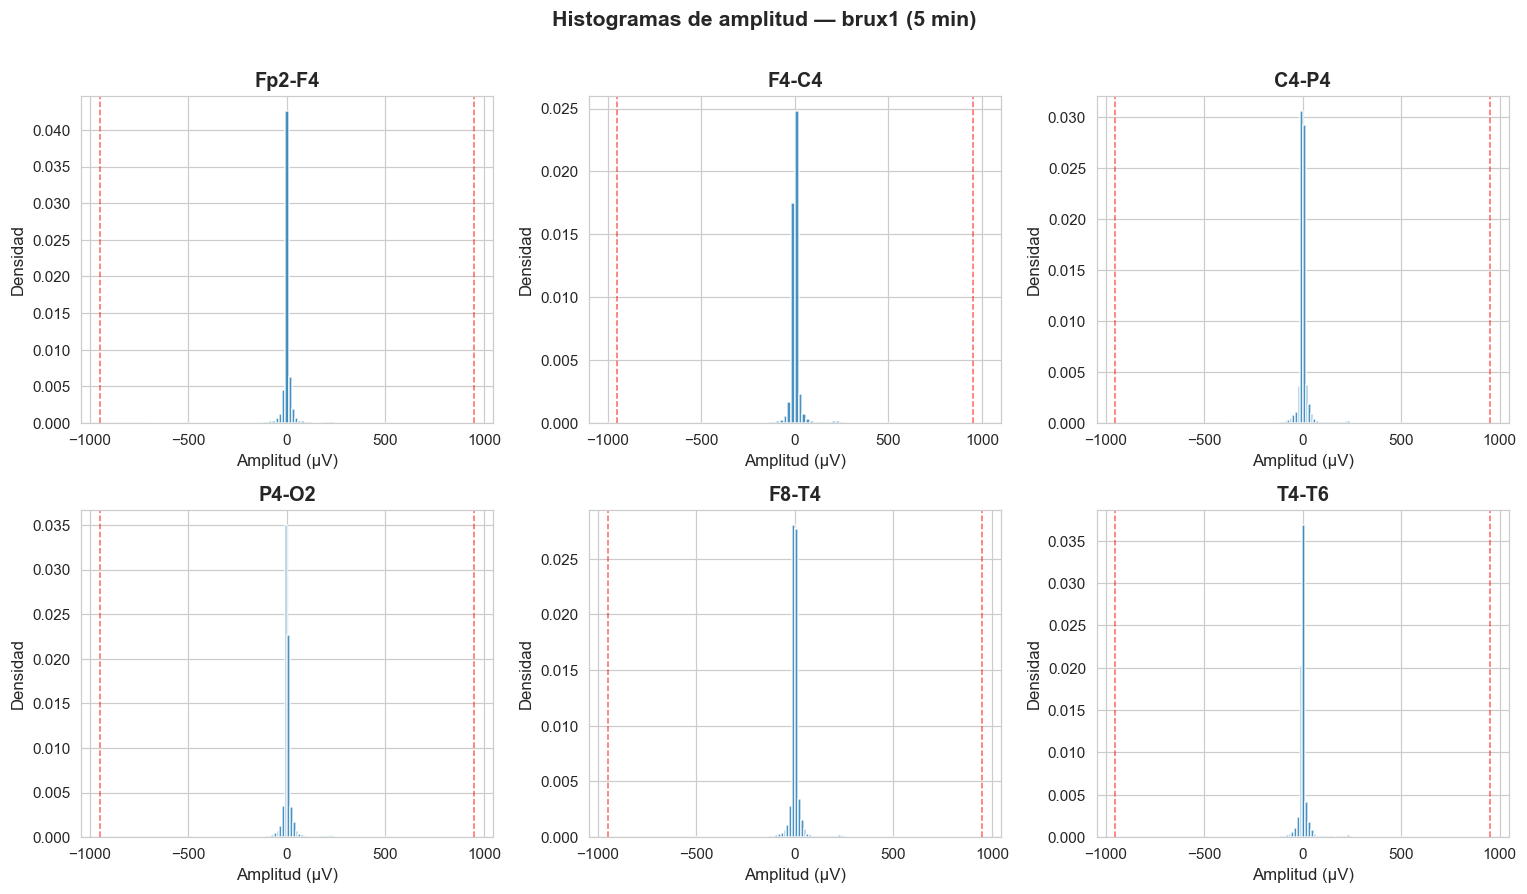

In [12]:
# Histogramas de canales EEG para un paciente
patient_hist = list(dataframes.keys())[0]
df_hist = dataframes[patient_hist]
sfreq_h = raws[patient_hist].info['sfreq']

# Tomar primeros 5 min y máximo 6 canales
n_5min  = int(5 * 60 * sfreq_h)
signal_cols = [c for c in df_hist.columns if c != 'time'][:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(signal_cols):
    data = df_hist[col].iloc[:n_5min].values
    axes[i].hist(data, bins=100, color='#2980B9', edgecolor='white', alpha=0.85, density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Amplitud (µV)')
    axes[i].set_ylabel('Densidad')
    
    # Marcar zona de saturación
    axes[i].axvline(950, color='red', ls='--', lw=1, alpha=0.6)
    axes[i].axvline(-950, color='red', ls='--', lw=1, alpha=0.6)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'Histogramas de amplitud — {patient_hist} (5 min)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 10. Gráficas de densidad (KDE)

Las gráficas KDE permiten visualizar la distribución continua de las señales sin los artefactos de discretización de los histogramas. Son útiles para comparar la forma de distribución entre canales y detectar señales con sesgo o distribuciones bimodales.


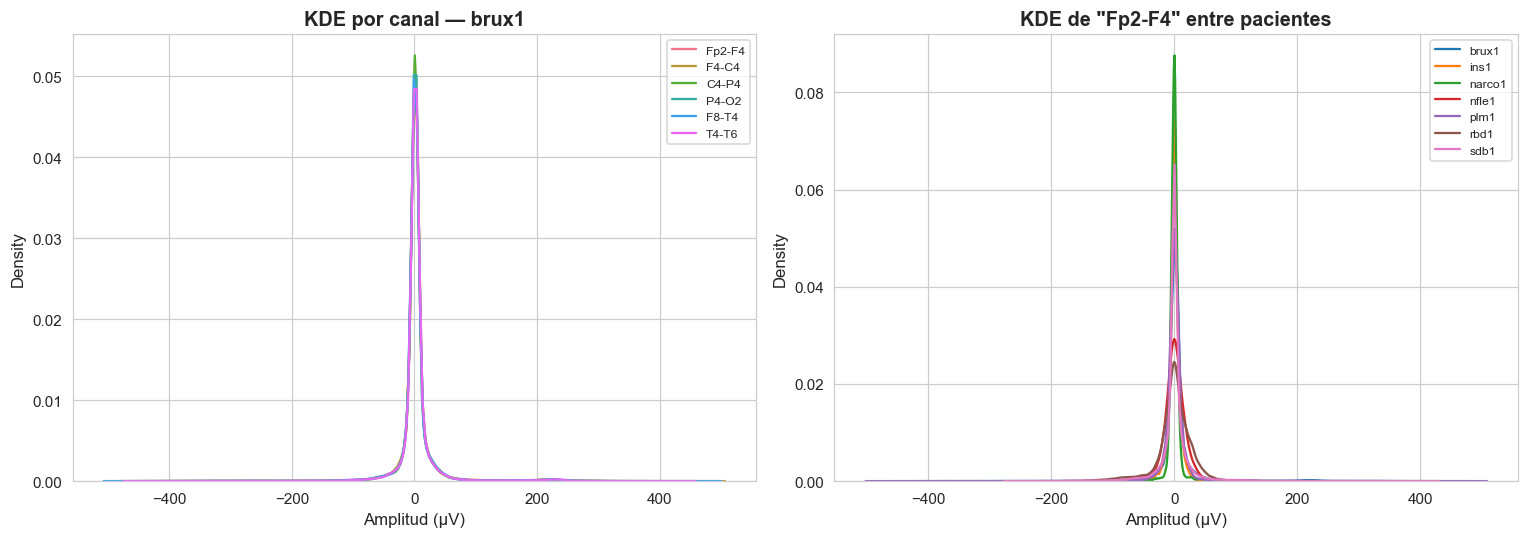

Observación: distribuciones centradas en 0 son normales para EEG.
Colas pesadas o asimetría indican artefactos o saturación.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE: comparar canales de un mismo paciente
patient_kde = list(dataframes.keys())[0]
df_kde = dataframes[patient_kde]
n_5min = int(5 * 60 * raws[patient_kde].info['sfreq'])
signal_cols = [c for c in df_kde.columns if c != 'time'][:6]

palette = sns.color_palette('husl', len(signal_cols))
for col, color in zip(signal_cols, palette):
    data = df_kde[col].iloc[:n_5min].values
    # Clip para visualización (excluir saturación)
    data_clip = data[(data > -500) & (data < 500)]
    sns.kdeplot(data_clip, ax=axes[0], label=col, color=color, linewidth=1.5)

axes[0].set_title(f'KDE por canal — {patient_kde}', fontweight='bold')
axes[0].set_xlabel('Amplitud (µV)')
axes[0].legend(fontsize=8)

# KDE: comparar mismo canal entre pacientes
canal_ref = None
for p, df in dataframes.items():
    cols = [c for c in df.columns if c != 'time']
    if canal_ref is None:
        canal_ref = cols[0]  # primer canal del primer paciente
    if canal_ref in cols:
        n = int(5 * 60 * raws[p].info['sfreq'])
        data = df[canal_ref].iloc[:n].values
        data_clip = data[(data > -500) & (data < 500)]
        if len(data_clip) > 100:
            sns.kdeplot(data_clip, ax=axes[1], label=p, linewidth=1.5)

axes[1].set_title(f'KDE de "{canal_ref}" entre pacientes', fontweight='bold')
axes[1].set_xlabel('Amplitud (µV)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Observación: distribuciones centradas en 0 son normales para EEG.')
print('Colas pesadas o asimetría indican artefactos o saturación.')


## 11. Boxplots

Los boxplots revelan la dispersión y la presencia de outliers en cada canal. En señales EEG, los outliers frecuentes con valores en ±1000 µV corresponden a saturación del amplificador y no a actividad cerebral real.


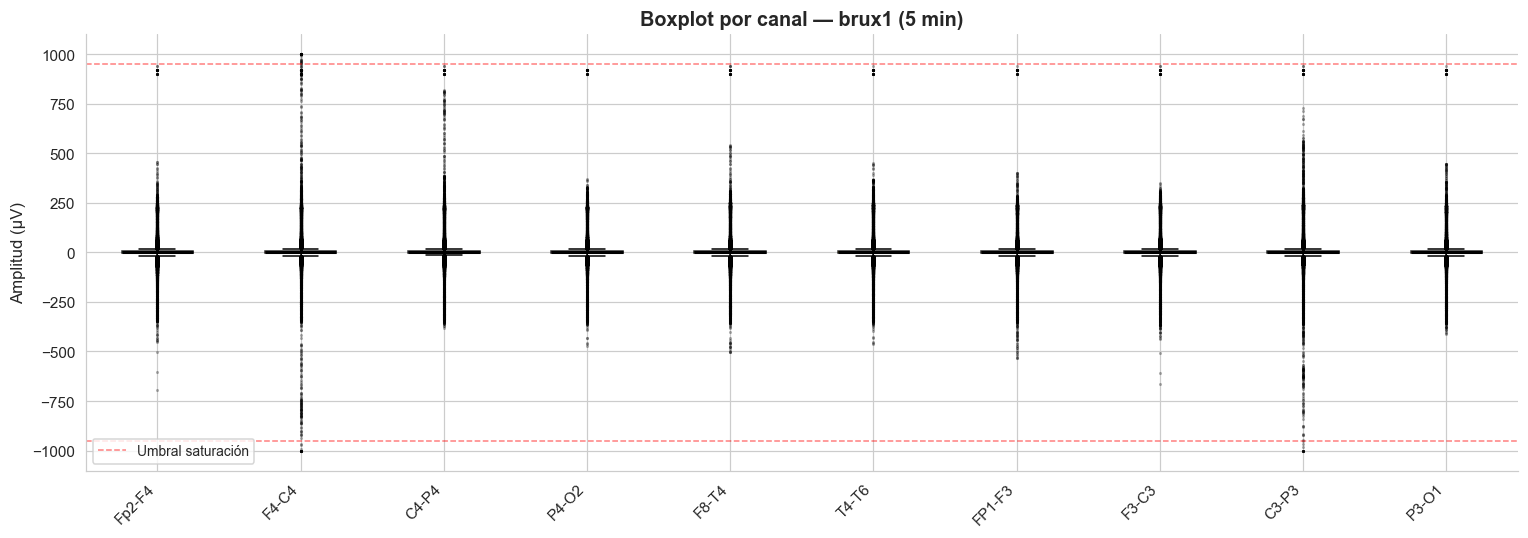


Estadísticas de rango intercuartil (IQR) — brux1:
Canal                      Q1       Q3      IQR   Outliers
--------------------------------------------------------
Fp2-F4                   -3.0      5.9      8.9     25,604
F4-C4                    -2.9      6.0      8.9     26,014
C4-P4                    -2.8      5.8      8.6     25,543
P4-O2                    -3.1      5.8      8.8     24,692
F8-T4                    -3.0      5.8      8.8     25,396
T4-T6                    -2.8      6.0      8.8     24,677
FP1-F3                   -3.1      5.8      8.9     25,864
F3-C3                    -3.2      5.8      8.9     25,741
C3-P3                    -3.2      5.8      9.0     24,550
P3-O1                    -3.0      5.8      8.8     25,401


In [14]:
patient_box = list(dataframes.keys())[0]
df_box = dataframes[patient_box]
n_5min = int(5 * 60 * raws[patient_box].info['sfreq'])
signal_cols = [c for c in df_box.columns if c != 'time'][:10]

fig, ax = plt.subplots(figsize=(14, 5))
data_box = df_box[signal_cols].iloc[:n_5min]

bp = ax.boxplot(
    [data_box[col].values for col in signal_cols],
    labels=signal_cols,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
    flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3},
)

palette = sns.color_palette('Set2', len(signal_cols))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_title(f'Boxplot por canal — {patient_box} (5 min)', fontweight='bold')
ax.set_ylabel('Amplitud (µV)')
ax.axhline(950, color='red', ls='--', lw=1, alpha=0.5, label='Umbral saturación')
ax.axhline(-950, color='red', ls='--', lw=1, alpha=0.5)
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

# Estadísticas de IQR
print(f'\nEstadísticas de rango intercuartil (IQR) — {patient_box}:')
print(f'{"Canal":<20} {"Q1":>8} {"Q3":>8} {"IQR":>8} {"Outliers":>10}')
print('-' * 56)
for col in signal_cols:
    q1 = data_box[col].quantile(0.25)
    q3 = data_box[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((data_box[col] < lower) | (data_box[col] > upper)).sum()
    print(f'{col:<20} {q1:>8.1f} {q3:>8.1f} {iqr:>8.1f} {n_out:>10,}')


## 12. Matriz de correlación (heatmap)

Visualización completa de la matriz de correlación usando un heatmap anotado.


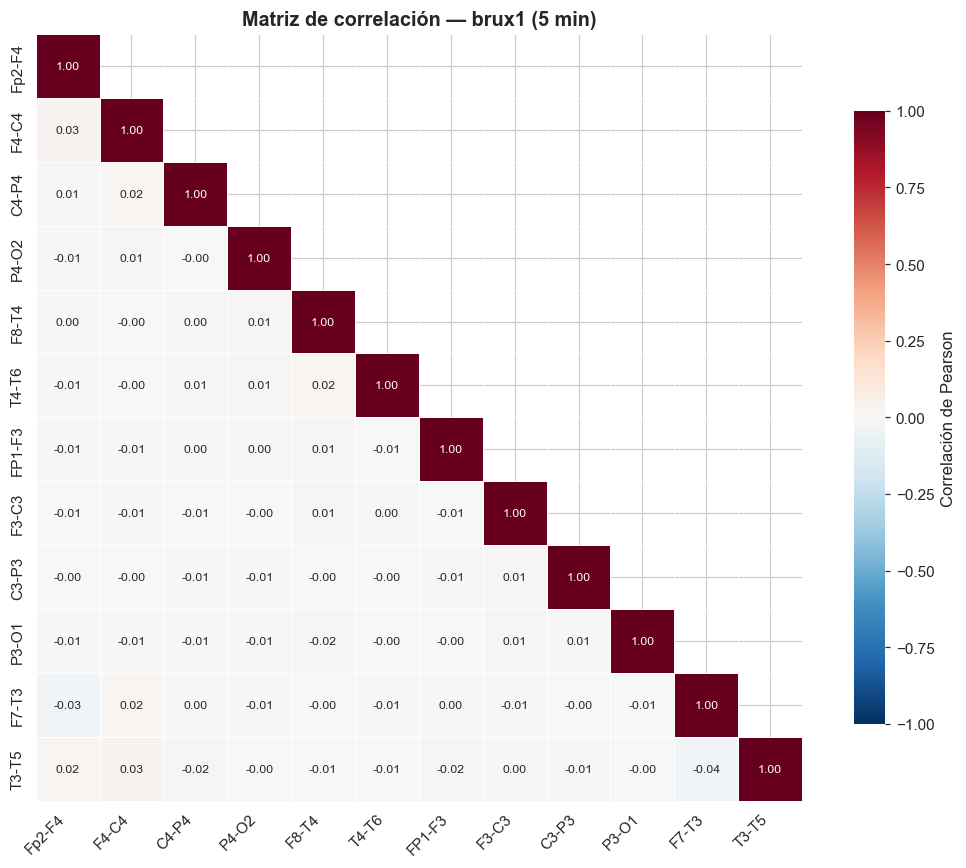

Interpretación:
  • Canales EEG cercanos (e.g., F3-C3 / F4-C4) muestran alta correlación positiva.
  • Canales de modalidades distintas (EEG vs ECG) muestran baja correlación.
  • Correlaciones negativas fuertes pueden indicar derivaciones diferenciales.


In [15]:
patient_hm = list(dataframes.keys())[0]
df_hm = dataframes[patient_hm]
sfreq_hm = raws[patient_hm].info['sfreq']
n_5min = int(5 * 60 * sfreq_hm)

cols_hm = [c for c in df_hm.columns if c != 'time'][:12]
corr_matrix = df_hm[cols_hm].iloc[:n_5min].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5, linecolor='white',
    square=True, ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'},
)
ax.set_title(f'Matriz de correlación — {patient_hm} (5 min)', fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Interpretación:')
print('  • Canales EEG cercanos (e.g., F3-C3 / F4-C4) muestran alta correlación positiva.')
print('  • Canales de modalidades distintas (EEG vs ECG) muestran baja correlación.')
print('  • Correlaciones negativas fuertes pueden indicar derivaciones diferenciales.')


## 13. Matriz de dispersión (pairplot)

Para evitar problemas de memoria, usamos un subconjunto de 4 canales y 10,000 muestras.


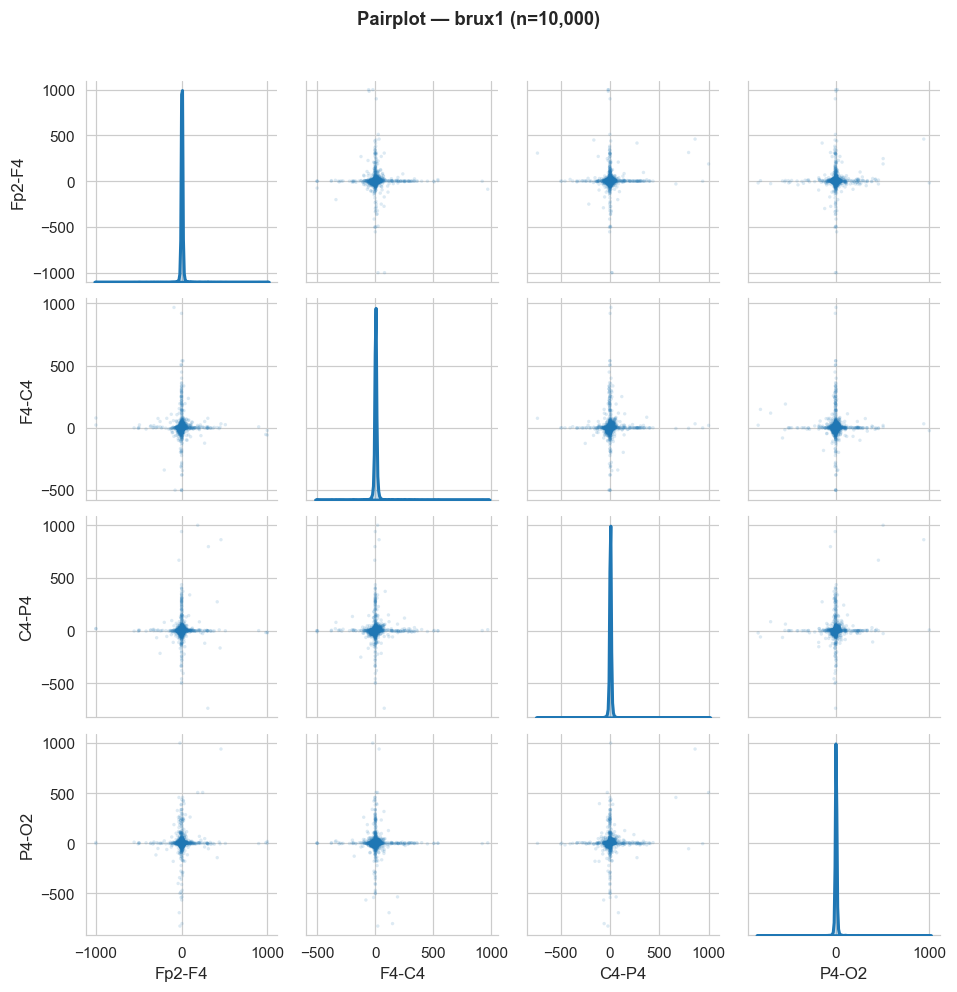

Nota: las nubes de puntos elípticas indican correlación lineal.
Nubes circulares indican independencia entre canales.


In [16]:
patient_pp = list(dataframes.keys())[0]
df_pp = dataframes[patient_pp]
cols_pp = [c for c in df_pp.columns if c != 'time'][:4]

# Submuestra aleatoria de 10,000 puntos
n_sub = min(10_000, len(df_pp))
df_scatter = df_pp[cols_pp].sample(n=n_sub, random_state=42)

g = sns.pairplot(
    df_scatter,
    diag_kind='kde',
    plot_kws={'alpha': 0.15, 's': 5, 'edgecolor': 'none'},
    diag_kws={'linewidth': 2},
    height=2.2,
)
g.fig.suptitle(f'Pairplot — {patient_pp} (n={n_sub:,})', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Nota: las nubes de puntos elípticas indican correlación lineal.')
print('Nubes circulares indican independencia entre canales.')


## 14. Escalamiento y normalización

En señales biomédicas, el escalamiento es crucial antes de alimentar modelos de ML. Comparamos tres métodos:

| Método | Fórmula | Cuándo usarlo |
|---|---|---|
| **StandardScaler** | z = (x - μ) / σ | Cuando los datos siguen distribución ~normal. **Recomendado para EEG.** |
| **MinMaxScaler** | x' = (x - min) / (max - min) | Cuando necesitas un rango fijo [0,1]. Sensible a outliers. |
| **Normalizer** | x' = x / ‖x‖ | Normaliza por fila (cada muestra). Útil para vectores de características. |

Para señales EEG, **StandardScaler** es generalmente el más adecuado porque:
- Las señales EEG son aproximadamente gaussianas
- Es robusto a diferencias de amplitud entre canales
- No colapsa la distribución ante outliers de saturación como MinMaxScaler


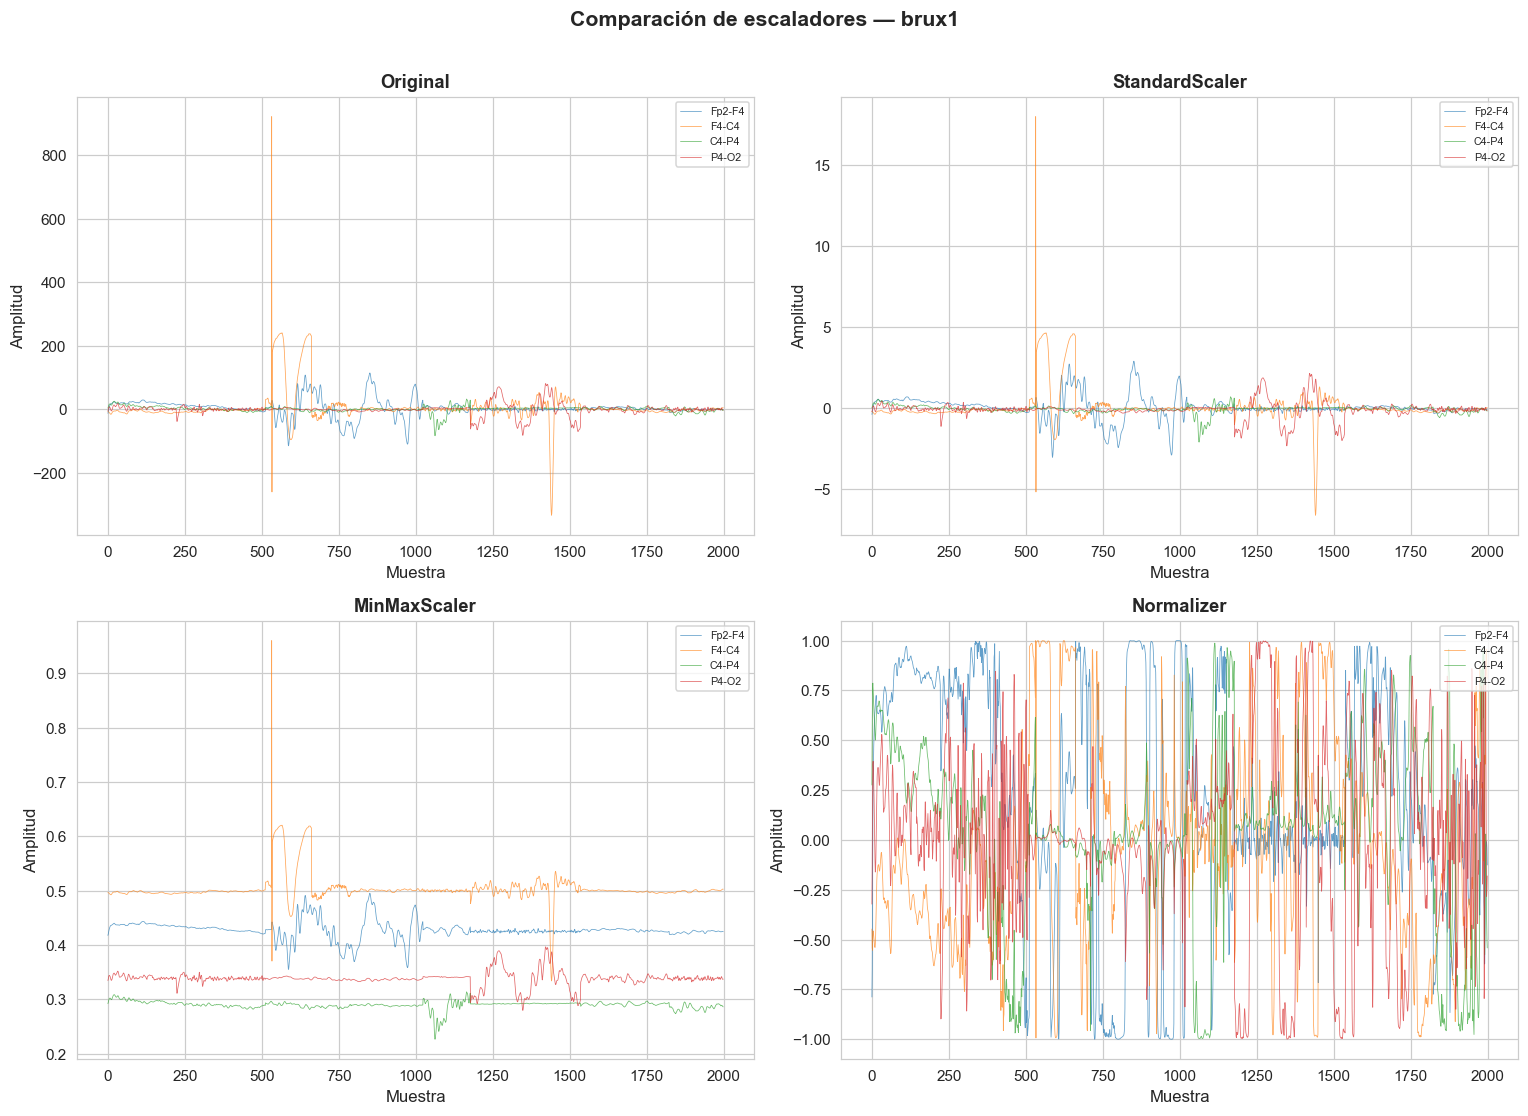

In [17]:
# Comparación visual de los tres métodos
patient_sc = list(dataframes.keys())[0]
df_sc = dataframes[patient_sc]
n_5min = int(5 * 60 * raws[patient_sc].info['sfreq'])
cols_sc = [c for c in df_sc.columns if c != 'time'][:4]
data_raw = df_sc[cols_sc].iloc[:n_5min].values

# Aplicar escaladores
scalers = {
    'Original':       data_raw,
    'StandardScaler': StandardScaler().fit_transform(data_raw),
    'MinMaxScaler':   MinMaxScaler().fit_transform(data_raw),
    'Normalizer':     Normalizer().fit_transform(data_raw),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, data) in enumerate(scalers.items()):
    ax = axes[idx]
    for j, col in enumerate(cols_sc):
        # Mostrar primeros 2000 samples
        ax.plot(data[:2000, j], label=col, alpha=0.7, linewidth=0.5)
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xlabel('Muestra')
    ax.set_ylabel('Amplitud')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle(f'Comparación de escaladores — {patient_sc}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [18]:
# Comparación estadística antes/después
print(f'Comparación de estadísticas — {patient_sc}, canal {cols_sc[0]}:')
print(f'{"Método":<18} {"Media":>10} {"DE":>10} {"Min":>10} {"Max":>10}')
print('-' * 58)

for name, data in scalers.items():
    col_data = data[:, 0]
    print(f'{name:<18} {col_data.mean():>10.4f} {col_data.std():>10.4f} {col_data.min():>10.4f} {col_data.max():>10.4f}')

print()
print('Recomendación para EEG: StandardScaler')
print('  → Media ≈ 0, DE ≈ 1, preserva la distribución de la señal.')
print('  → MinMaxScaler colapsa el rango útil si hay saturación en ±1000.')


Comparación de estadísticas — brux1, canal Fp2-F4:
Método                  Media         DE        Min        Max
----------------------------------------------------------
Original               3.2649    38.6580  -695.2534   940.6136
StandardScaler         0.0000     1.0000   -18.0692    24.2472
MinMaxScaler           0.4270     0.0236     0.0000     1.0000
Normalizer             0.0550     0.4976    -1.0000     1.0000

Recomendación para EEG: StandardScaler
  → Media ≈ 0, DE ≈ 1, preserva la distribución de la señal.
  → MinMaxScaler colapsa el rango útil si hay saturación en ±1000.


## 15. Análisis final y conclusiones


In [19]:
# ── Resumen de hallazgos ──────────────────────────────────────
n_patients = stages_all['patient'].nunique()
n_epochs   = len(stages_all)
n_cap      = len(cap_all)
disorders  = stages_all[['patient','disorder']].drop_duplicates()['disorder'].value_counts()

print('='*65)
print('  ANÁLISIS FINAL — CAP Sleep Database')
print('='*65)

print(f'''
📊 DIMENSIONES DEL DATASET
  Pacientes totales      : {n_patients}
  Épocas de hipnograma   : {n_epochs:,}
  Eventos CAP-A          : {n_cap:,}
  Etapas del sueño       : W, N1, N2, N3, REM, MT
  Subtipos CAP           : CAP-A1, CAP-A2, CAP-A3
  Frecuencias de muestreo: 100, 128, 200, 256, 512 Hz (modal: 512 Hz)

📋 CALIDAD DE LOS DATOS
  ✅ Sin valores nulos en las señales EDF
  ✅ Todas las columnas son numéricas (float64)
  ✅ 108/108 pacientes con anotaciones de hipnograma y CAP
  ⚠️  Heterogeneidad de canales (5–36 por paciente)
  ⚠️  Nomenclatura inconsistente entre centros
  ⚠️  Pacientes n13 y n14 con saturación EEG al 100%%
  ⚠️  5 frecuencias de muestreo distintas

🔊 RUIDO Y ARTEFACTOS
  • Saturación de amplificador detectable en ±1000 µV
  • Canales de rango fijo (SAO2, HR, PLETH) muestran
    saturación esperada, no artefactual
  • Señales respiratorias con clipping elevado (~20-44%%)
  • Canal POSITION codifica posición corporal, no es señal PSG

📊 CORRELACIONES RELEVANTES
  • Canales EEG de hemisferios opuestos (e.g., C3 vs C4)
    muestran alta correlación → actividad cerebral sincronizada
  • Baja correlación EEG-ECG → modalidades independientes
  • Canales adyacentes del mismo montaje → correlación esperada
    por volumen de conducción

🤖 UTILIDAD PARA MACHINE LEARNING
  ✅ Señales multimodales (EEG, EMG, ECG) para clasificación
  ✅ Anotaciones expertas de hipnograma y CAP disponibles
  ⚠️  Desbalance severo: NFLE 37%% vs Bruxismo 1.9%%
  ⚠️  Se requiere resampleo a frecuencia común (256 Hz sugerido)
  ⚠️  Normalización de canales necesaria antes de extracción
     de características

⚡ PREPROCESAMIENTO RECOMENDADO
  1. Excluir pacientes n13 y n14 (saturación completa)
  2. Resamplear a 256 Hz (mínimo común razonable)
  3. Normalizar nomenclatura con CHANNEL_MAPPING extendido
  4. Aplicar StandardScaler por canal antes de ML
  5. Usar tiempo de sueño efectivo para normalizar métricas
  6. Evaluar estrategias de balanceo (SMOTE, ponderación)
     antes de clasificación supervisada
''')


  ANÁLISIS FINAL — CAP Sleep Database

📊 DIMENSIONES DEL DATASET
  Pacientes totales      : 108
  Épocas de hipnograma   : 106,355
  Eventos CAP-A          : 49,956
  Etapas del sueño       : W, N1, N2, N3, REM, MT
  Subtipos CAP           : CAP-A1, CAP-A2, CAP-A3
  Frecuencias de muestreo: 100, 128, 200, 256, 512 Hz (modal: 512 Hz)

📋 CALIDAD DE LOS DATOS
  ✅ Sin valores nulos en las señales EDF
  ✅ Todas las columnas son numéricas (float64)
  ✅ 108/108 pacientes con anotaciones de hipnograma y CAP
  ⚠️  Heterogeneidad de canales (5–36 por paciente)
  ⚠️  Nomenclatura inconsistente entre centros
  ⚠️  Pacientes n13 y n14 con saturación EEG al 100%%
  ⚠️  5 frecuencias de muestreo distintas

🔊 RUIDO Y ARTEFACTOS
  • Saturación de amplificador detectable en ±1000 µV
  • Canales de rango fijo (SAO2, HR, PLETH) muestran
    saturación esperada, no artefactual
  • Señales respiratorias con clipping elevado (~20-44%%)
  • Canal POSITION codifica posición corporal, no es señal PSG

📊 CORRELA